In [19]:
# Import basic libraries for data manipulation
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning utilities from Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import roc_curve, precision_recall_curve

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# XGBoost model
from xgboost import XGBClassifier

# Handling class imbalance
from imblearn.over_sampling import SMOTE

# Explainable AI library
import shap

# Library to save trained models
import joblib

In [20]:
# Import kagglehub to download dataset directly from Kaggle
import kagglehub
import os

# Download dataset
path = kagglehub.dataset_download("johnsmith88/heart-disease-dataset")

print("Dataset path:", path)

# List files inside downloaded folder
files = os.listdir(path)
print(files)

# Load the dataset into a pandas DataFrame
df = pd.read_csv(os.path.join(path, files[0]))

# Display first few rows
df.head()

Using Colab cache for faster access to the 'heart-disease-dataset' dataset.
Dataset path: /kaggle/input/heart-disease-dataset
['heart.csv']


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [21]:
# Check dataset shape (rows and columns)
print(df.shape)

# Display information about columns and datatypes
df.info()

# Statistical summary of numerical features
df.describe()

# Check for missing values
print(df.isnull().sum())

(1025, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: in

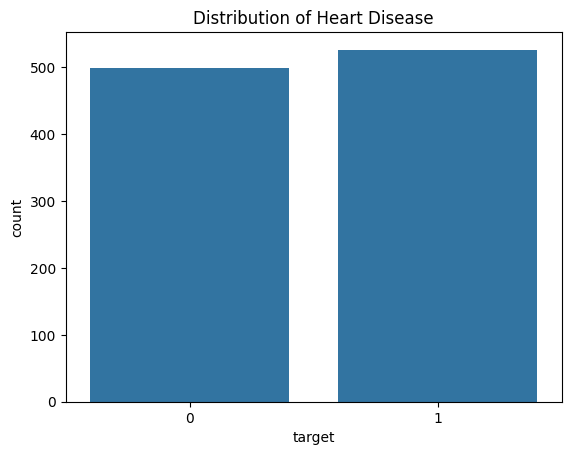

In [22]:
# Visualize how many patients have heart disease vs not
sns.countplot(x="target", data=df)

plt.title("Distribution of Heart Disease")
plt.show()

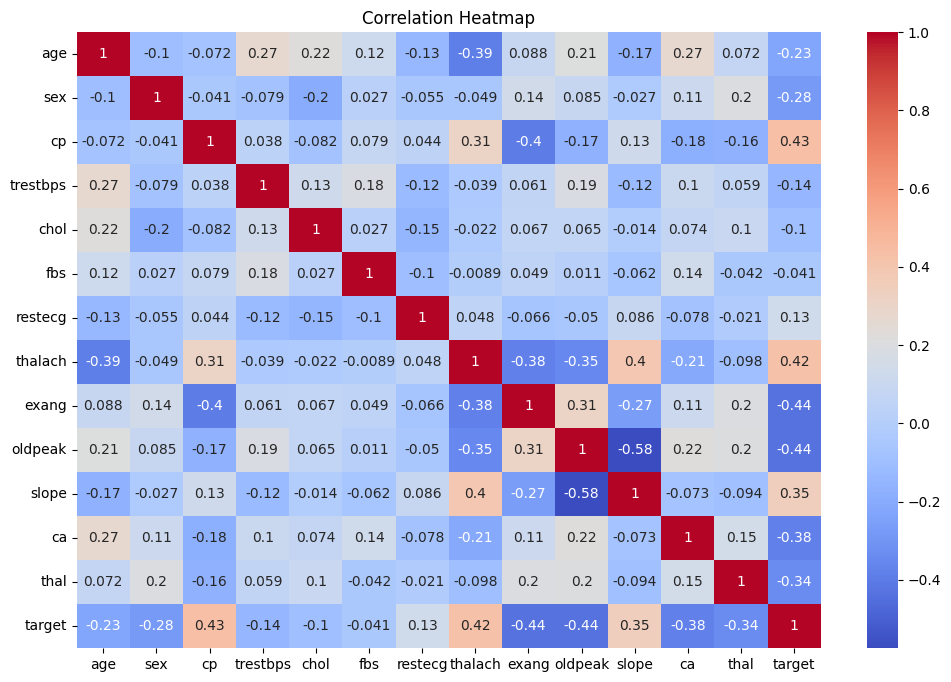

In [23]:
# Correlation matrix helps understand relationships between variables
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

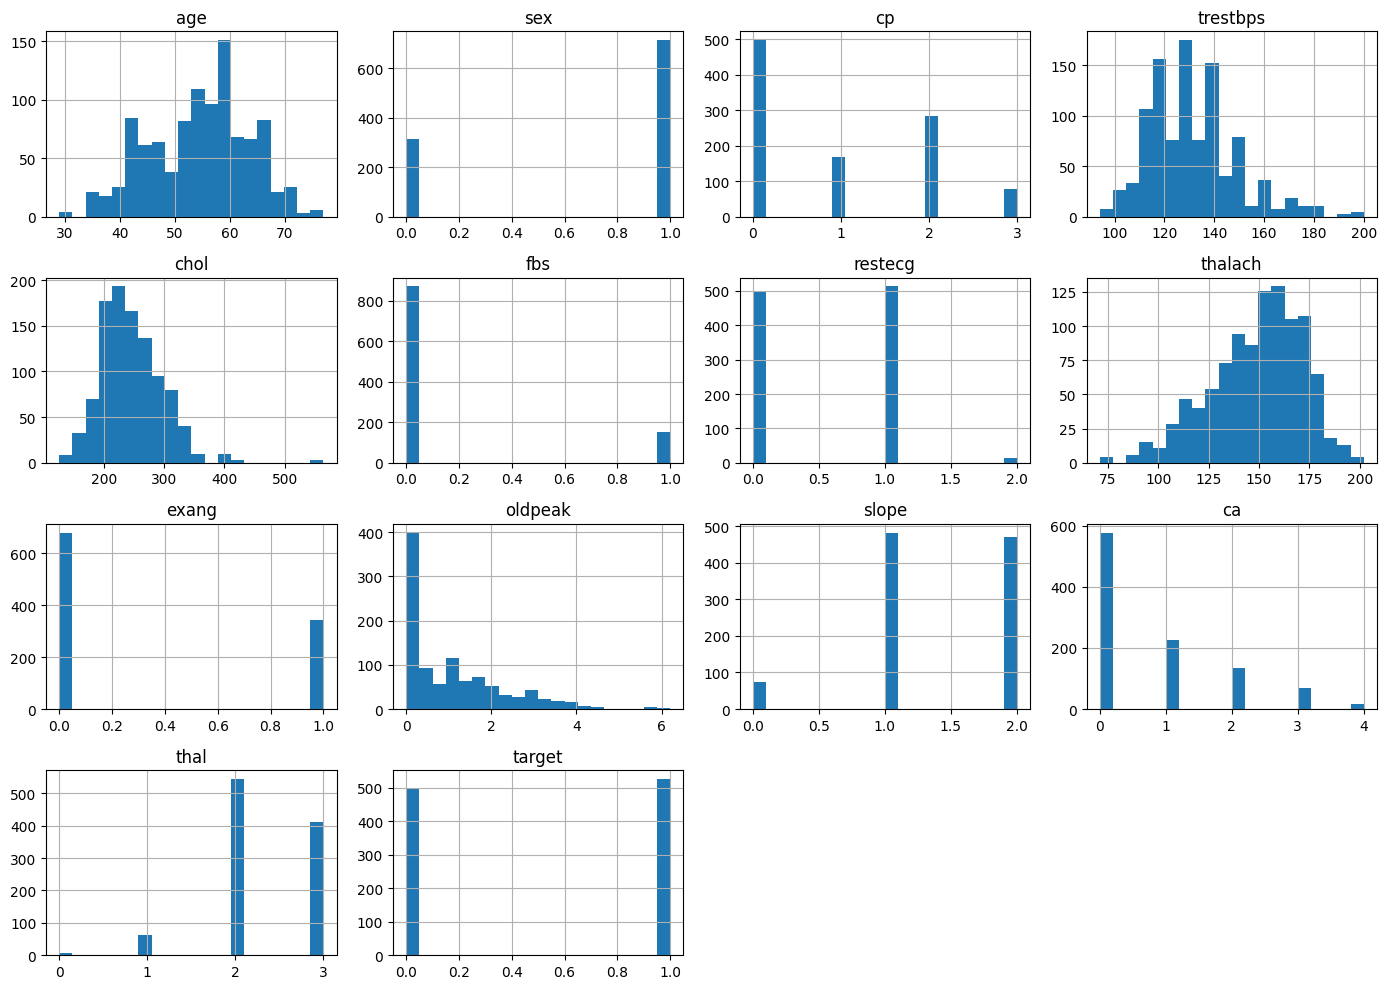

In [24]:
# Visualize distribution of each feature
df.hist(figsize=(14,10), bins=20)

plt.tight_layout()
plt.show()

In [26]:
# Separate features (X) and target variable (y)

X = df.drop("target", axis=1)   # All columns except target
y = df["target"]                # Target column

In [27]:
# Split dataset into training and testing sets
# 80% training, 20% testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [28]:
# Standardization improves performance of many ML algorithms

scaler = StandardScaler()

# Fit scaler on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using same scaler
X_test_scaled = scaler.transform(X_test)

In [29]:
# SMOTE creates synthetic samples for minority class
# Helps avoid bias toward majority class

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled,
    y_train
)

# Check class distribution after SMOTE
print("Class distribution after SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

Class distribution after SMOTE:
target
0    421
1    421
Name: count, dtype: int64


In [30]:
# Create Logistic Regression model
lr_model = LogisticRegression()

# Train the model
lr_model.fit(X_train_resampled, y_train_resampled)

# Make predictions
y_pred_lr = lr_model.predict(X_test_scaled)

# Prediction probabilities for ROC-AUC
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:,1]

# Model evaluation
print("Logistic Regression Results")

print(classification_report(y_test, y_pred_lr))

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_lr))

Logistic Regression Results
              precision    recall  f1-score   support

           0       0.89      0.70      0.78       100
           1       0.76      0.91      0.83       105

    accuracy                           0.81       205
   macro avg       0.82      0.81      0.81       205
weighted avg       0.82      0.81      0.81       205

ROC-AUC Score: 0.9294285714285715


In [31]:
# Create Random Forest classifier
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

# Train model
rf_model.fit(X_train_resampled, y_train_resampled)

# Predictions
y_pred_rf = rf_model.predict(X_test_scaled)

# Probability predictions
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:,1]

# Evaluation
print("Random Forest Results")

print(classification_report(y_test, y_pred_rf))

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_rf))

Random Forest Results
              precision    recall  f1-score   support

           0       0.97      0.96      0.96       100
           1       0.96      0.97      0.97       105

    accuracy                           0.97       205
   macro avg       0.97      0.97      0.97       205
weighted avg       0.97      0.97      0.97       205

ROC-AUC Score: 0.989904761904762


In [32]:
# Create XGBoost classifier
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    eval_metric='logloss',
    random_state=42
)

# Train model
xgb_model.fit(X_train_resampled, y_train_resampled)

# Predictions
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Probability predictions
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:,1]

# Evaluation
print("XGBoost Results")

print(classification_report(y_test, y_pred_xgb))

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_xgb))

XGBoost Results
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       100
           1       0.98      1.00      0.99       105

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205

ROC-AUC Score: 1.0


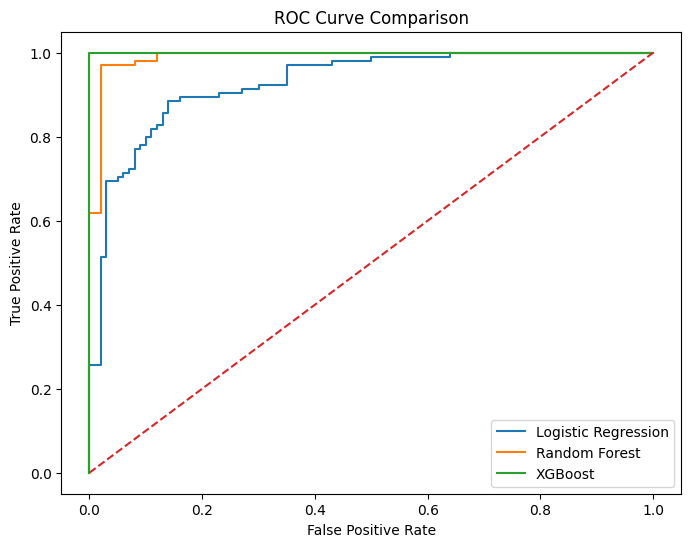

In [33]:
# Compute ROC curves for all models
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

# Plot ROC curves
plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")

# Diagonal baseline
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()

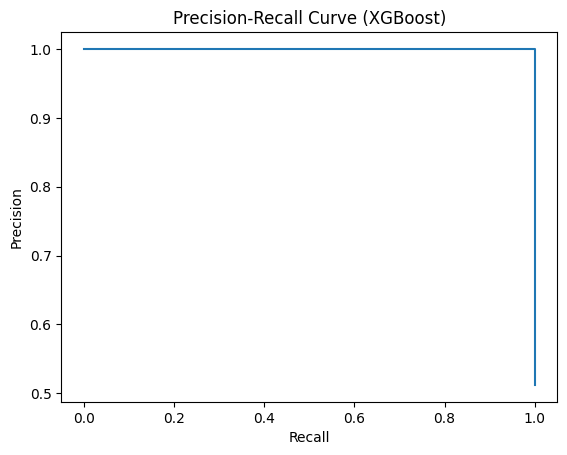

In [34]:
# Compute precision-recall values
precision, recall, _ = precision_recall_curve(y_test, y_prob_xgb)

# Plot precision-recall curve
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve (XGBoost)")

plt.show()

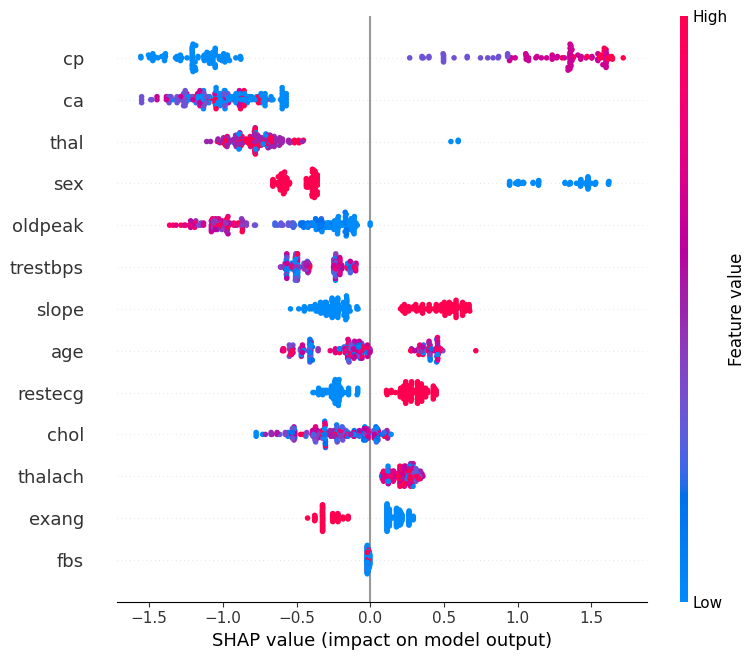

In [35]:
# SHAP explains which features contribute most to predictions

explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

# Plot feature importance summary
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X.columns
)

In [36]:
# Save trained model for deployment
joblib.dump(xgb_model, "heart_model.pkl")

# Save scaler as well
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully")

Model and scaler saved successfully
